# Imports

In [1]:
import math
import os
import sys

import numpy as np
import torch
from torchvision.transforms import GaussianBlur
from IPython.core.pylabtools import figsize
from mpmath.identification import transforms
import matplotlib.pyplot as plt
from torchvision.transforms.v2 import RandomApply

from utils.checkpoint import load_checkpoint, save_checkpoint, load_model
from utils.data import get_dataloaders, get_img_from_loader
from evaluate import evaluate, evaluate_with_uncertainty

sys.path.append("..")

from models.lenet import Net as LeNet
from config import Config

from utils.corruptions import gaussian_blur, test_on_corruptions, corruptions_uncertainty
from utils.data import get_img_from_loader



In [2]:
torch.manual_seed(42)

config = Config()
device = config.device
T = 10

# Model
mnist_model = LeNet(
    prior_sigma1=math.exp(0),
    prior_sigma2=math.exp(-6),
    prior_pi=0.5,
    num_classes=10,
    rho_init=-4.5
).to(device)

emnist_model = LeNet(
    prior_sigma1=math.exp(-0.8470609173270909),
    prior_sigma2=math.exp(-7.293222293379696),
    prior_pi=0.44622172885322486,
    num_classes=26,
    rho_init=-5.724956071835678
).to(device)

# Optimizer (needed to load checkpoint)
optimizer = torch.optim.Adam(emnist_model.parameters(), lr=config.learning_rate)
# Load weights
config.model_name = 'lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1'
load_model(emnist_model, f'{config.checkpoint_path}/{config.model_name}/{config.model_name}_20260317.pth', device)
config.model_name = 'lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1'
load_checkpoint(mnist_model, optimizer, f'{config.checkpoint_path}/{config.model_name}/{config.get_checkpoint_name(190, date="20260129")}', device)

[model] Loaded from ../checkpoints/lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1/lenet_emnist_lrp9p426em04_logprior1mp847_logprior2m7p293_priorpip446_rhoinit_m5p724_batch_64_v1_20260317.pth
[checkpoint] Loaded from ../checkpoints/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1/lenet_mnist_lrp1em04_logprior10_logprior2m6_priorpip5_v1_epoch_190_20260129.pth, starting at epoch 191


191

# EMNIST vs MNIST

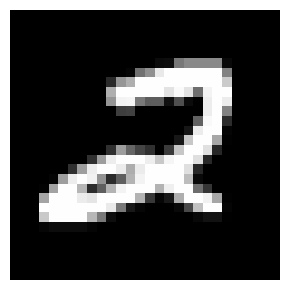

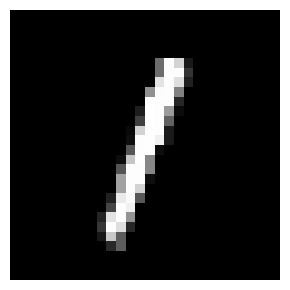

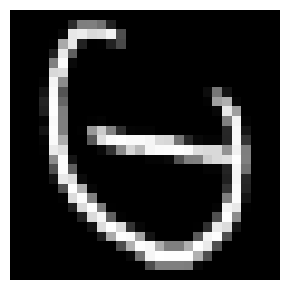

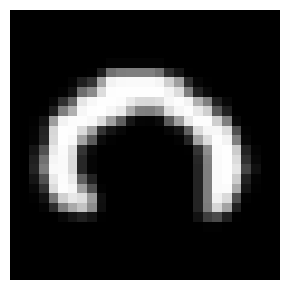

In [8]:
# plot two examples from mnist and emnist
emnist_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
    dataset="EMNIST",
    dataset_kwargs={"split": "letters"},
)[0]
mnist_loader = get_dataloaders(
    data_dir="../data",
    batch_size=config.test_batch_size,
    num_workers=config.num_workers,
    use_cuda=torch.cuda.is_available(),
)[0]

for batch_idx in range(2):
    mnist_img, mnist_label = get_img_from_loader(mnist_loader, batch_idx=batch_idx, img_idx=0, device=config.device)

    fig, axes = plt.subplots(figsize=(6, 3))
    axes.imshow(mnist_img.cpu().squeeze(), cmap='gray')
    axes.axis('off')
    plt.tight_layout()
    plt.show()

for batch_idx in range(2):
    emnist_img, emnist_label = get_img_from_loader(emnist_loader, batch_idx=batch_idx, img_idx=2, device=config.device)

    fig, axes = plt.subplots(figsize=(6, 3))
    axes.imshow(emnist_img.cpu().squeeze(), cmap='gray')
    axes.axis('off')
    plt.tight_layout()
    plt.show()

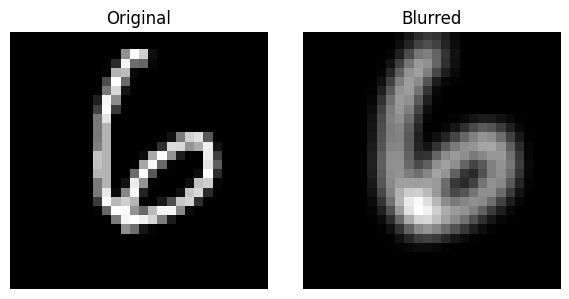

In [26]:
kernel_size = 5

batch_idx = 0
mnist_img, mnist_label = get_img_from_loader(mnist_loader, batch_idx=batch_idx, img_idx=0, device=config.device)

# Применяем гауссовское размытие
gaussian_blur_transform = GaussianBlur(kernel_size=kernel_size)
blurred_mnist_img = gaussian_blur_transform(mnist_img)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].set_title("Original")
axes[1].set_title(f"Blurred")
axes[0].imshow(mnist_img.cpu().squeeze(), cmap='gray')
axes[0].axis('off')
axes[1].imshow(blurred_mnist_img.cpu().squeeze(), cmap='gray')
axes[1].axis('off')
plt.tight_layout()
plt.show()



# Вычисление точности с гауссовским размытием

In [ ]:
from tqdm import tqdm

kernel_sizes = [1, 3, 5, 7, 9]


## EMNIST-letters

In [11]:
accuracies = []
total_unc = []
alea_unc = []
epis_unc = []

loop = tqdm(kernel_sizes, desc=f"Calculating Accuracy and Uncertainties on EMNIST-letters dataset with Gaussian Blur")
for kernel_size in loop:
    blurred_test_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        dataset="EMNIST",
        dataset_kwargs={"split": "letters"},
        extra_transforms=[
            GaussianBlur(kernel_size)
        ]
    )[2]  # Получаем только тестовый загрузчик

    test_accuracy = evaluate(emnist_model, blurred_test_loader, device=config.device)
    _, uncertainties = evaluate_with_uncertainty(emnist_model, blurred_test_loader, device=config.device, mc_samples=T)
    accuracies.append(test_accuracy)
    total_unc.append(uncertainties[0].mean().item())
    alea_unc.append(uncertainties[1].mean().item())
    epis_unc.append(uncertainties[2].mean().item())

Calculating Accuracy and Uncertainties on EMNIST-letters dataset with Gaussian Blur: 100%|██████████| 5/5 [09:13<00:00, 110.80s/it]


## MNIST

In [13]:
from tqdm import tqdm

mnist_accuracies = []
mnist_total_unc = []
mnist_alea_unc = []
mnist_epis_unc = []

loop = tqdm(kernel_sizes, desc=f"Calculating Accuracy and Uncertainties for MNIST dataset with Gaussian Blur")
for kernel_size in loop:
    blurred_test_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        extra_transforms=[
            GaussianBlur(kernel_size)
        ]
    )[2]  # Получаем только тестовый загрузчик

    test_accuracy = evaluate(mnist_model, blurred_test_loader, device=config.device)
    _, uncertainties = evaluate_with_uncertainty(mnist_model, blurred_test_loader, device=config.device, mc_samples=T)
    mnist_accuracies.append(test_accuracy)
    mnist_total_unc.append(uncertainties[0].mean().item())
    mnist_alea_unc.append(uncertainties[1].mean().item())
    mnist_epis_unc.append(uncertainties[2].mean().item())

Calculating Accuracy and Uncertainties for MNIST dataset with Gaussian Blur: 100%|██████████| 5/5 [04:39<00:00, 55.84s/it]


## Графики

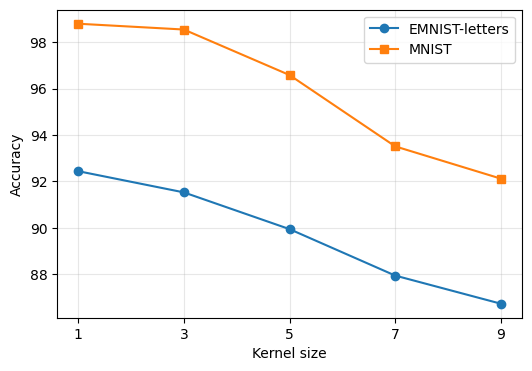

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))

colors = {'E': 'C0', 'M': 'C1'}

ax.plot(kernel_sizes, accuracies, color=colors['E'], label="EMNIST-letters", marker='o')
ax.plot(kernel_sizes, mnist_accuracies, color=colors['M'], label="MNIST", marker='s')

ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel size")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

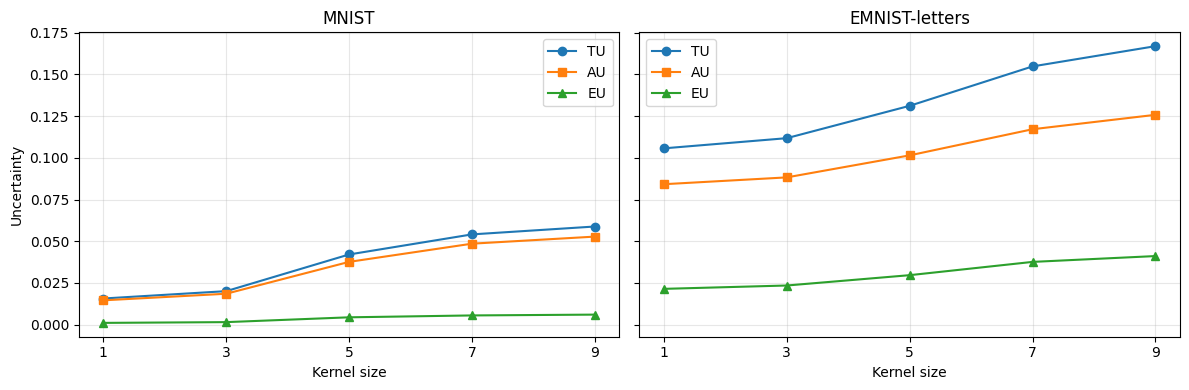

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

colors = {'TU': 'C0', 'AU': 'C1', 'EU': 'C2'}

# Левый subplot — MNIST
axes[0].plot(kernel_sizes, mnist_total_unc, label='TU', marker='o', color=colors['TU'])
axes[0].plot(kernel_sizes, mnist_alea_unc,  label='AU', marker='s', color=colors['AU'])
axes[0].plot(kernel_sizes, mnist_epis_unc,  label='EU', marker='^', color=colors['EU'])
axes[0].set_title('MNIST')
axes[0].set_xlabel('Kernel size')
axes[0].set_ylabel('Uncertainty')
axes[0].set_xticks(kernel_sizes)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Правый subplot — EMNIST-letters
axes[1].plot(kernel_sizes, total_unc, label='TU', marker='o', color=colors['TU'])
axes[1].plot(kernel_sizes, alea_unc,  label='AU', marker='s', color=colors['AU'])
axes[1].plot(kernel_sizes, epis_unc,  label='EU', marker='^', color=colors['EU'])
axes[1].set_title('EMNIST-letters')
axes[1].set_xlabel('Kernel size')
axes[1].set_xticks(kernel_sizes)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


# Зависимость неопределенности модели от правильности предсказаний

In [35]:
# Анализ корреляции между неопределенностью и правильностью предсказаний для разных уровней размытия
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision.transforms import GaussianBlur
from utils.uncertainty import mc_predict, quantify_uncertainties

T = 10
kernel_sizes = [1, 3, 5, 7, 9]

## EMNIST-letters

In [67]:
emnist_correlations = []
emnist_mean_unc_correct = []
emnist_mean_unc_incorrect = []
emnist_mean_aunc_correct = []
emnist_mean_aunc_incorrect = []
emnist_mean_eunc_correct = []
emnist_mean_eunc_incorrect = []

for ks in kernel_sizes:
    current_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        dataset="EMNIST",
        dataset_kwargs={"split": "letters"},
        extra_transforms=[GaussianBlur(ks)]
    )[2]
    desc = f"Blur {ks}"

    all_correct = []
    all_conf = []
    all_uncertainties = []
    all_aleatoric = []
    all_epistemic = []

    print(f"Processing {desc}...")
    for x, y in tqdm(current_loader, leave=False):
        x, y = x.to(device), y.to(device)

        # Оценка неопределенности
        mc_preds = mc_predict(emnist_model, x, mc_samples=T)
        preds, (total_unc_mat, alea_unc_mat, _) = quantify_uncertainties(mc_preds)

        # Извлекаем диагональ (дисперсию для каждого класса) и суммируем
        unc = total_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        aunc = alea_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        correct = (preds == y).float()

        # Softmax probability of the predicted class (mean over MC samples)
        mean_probs = mc_preds.mean(0)  # [batch, num_classes]
        pred_conf = mean_probs[torch.arange(len(preds)), preds]  # [batch]
        true_conf = mean_probs[torch.arange(len(y)), y]  # [batch]

        all_correct.append(correct.cpu().numpy())
        all_conf.append(true_conf.cpu().numpy())
        all_uncertainties.append(unc.cpu().numpy())
        all_aleatoric.append(aunc.cpu().numpy())
        all_epistemic.append((unc - aunc).cpu().numpy())

    c_vec = np.concatenate(all_correct)
    conf_vec = np.concatenate(all_conf)
    u_vec = np.concatenate(all_uncertainties)
    au_vec = np.concatenate(all_aleatoric)
    eu_vec = np.concatenate(all_epistemic)
    eunc_mean = np.mean(eu_vec)
    aunc_mean = np.mean(au_vec)
    print(f"Kernel {ks}: E[epistemic]={eunc_mean:.6f}, E[aleatoric]={aunc_mean:.6f}, ratio={eunc_mean/aunc_mean:.4f}")

    # Считаем корреляцию (softmax confidence of predicted class vs uncertainty)
    corr = np.corrcoef(conf_vec, u_vec)[0, 1]
    emnist_correlations.append(corr)

    # Считаем среднюю неопределенность для верных и неверных ответов
    emnist_mean_unc_correct.append(u_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    emnist_mean_unc_incorrect.append(u_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    emnist_mean_aunc_correct.append(au_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    emnist_mean_aunc_incorrect.append(au_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    emnist_mean_eunc_correct.append(eu_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    emnist_mean_eunc_incorrect.append(eu_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)

Processing Blur 1...


Kernel 1: E[epistemic]=0.021963, E[aleatoric]=0.084604, ratio=0.2596
Processing Blur 3...


Kernel 3: E[epistemic]=0.023822, E[aleatoric]=0.087925, ratio=0.2709
Processing Blur 5...


Kernel 5: E[epistemic]=0.030406, E[aleatoric]=0.101860, ratio=0.2985
Processing Blur 7...


Kernel 7: E[epistemic]=0.037830, E[aleatoric]=0.116889, ratio=0.3236
Processing Blur 9...


Kernel 9: E[epistemic]=0.040722, E[aleatoric]=0.124605, ratio=0.3268


## MNIST

In [68]:
mnist_correlations = []
mnist_mean_unc_correct = []
mnist_mean_unc_incorrect = []
mnist_mean_aunc_correct = []
mnist_mean_aunc_incorrect = []
mnist_mean_eunc_correct = []
mnist_mean_eunc_incorrect = []

for ks in kernel_sizes:
    current_loader = get_dataloaders(
        data_dir="../data",
        batch_size=config.test_batch_size,
        num_workers=config.num_workers,
        use_cuda=torch.cuda.is_available(),
        extra_transforms=[GaussianBlur(ks)]
    )[2]
    desc = f"Blur {ks}"

    all_correct = []
    all_conf = []
    all_uncertainties = []
    all_aleatoric = []
    all_epistemic = []

    print(f"Processing {desc}...")
    for x, y in tqdm(current_loader, leave=False):
        x, y = x.to(device), y.to(device)

        # Оценка неопределенности
        mc_preds = mc_predict(mnist_model, x, mc_samples=T)
        preds, (total_unc_mat, alea_unc_mat, _) = quantify_uncertainties(mc_preds)

        # Извлекаем диагональ (дисперсию для каждого класса) и суммируем
        unc = total_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        aunc = alea_unc_mat.diagonal(dim1=1, dim2=2).sum(-1)
        correct = (preds == y).float()

        # Softmax probability of the predicted class (mean over MC samples)
        mean_probs = mc_preds.mean(0)  # [batch, num_classes]
        pred_conf = mean_probs[torch.arange(len(preds)), preds]  # [batch]
        true_conf = mean_probs[torch.arange(len(y)), y]  # [batch]

        all_correct.append(correct.cpu().numpy())
        all_conf.append(true_conf.cpu().numpy())
        all_uncertainties.append(unc.cpu().numpy())
        all_aleatoric.append(aunc.cpu().numpy())
        all_epistemic.append((unc - aunc).cpu().numpy())

    c_vec = np.concatenate(all_correct)
    conf_vec = np.concatenate(all_conf)
    u_vec = np.concatenate(all_uncertainties)
    au_vec = np.concatenate(all_aleatoric)
    eu_vec = np.concatenate(all_epistemic)
    eunc_mean = np.mean(eu_vec)
    aunc_mean = np.mean(au_vec)
    print(f"Kernel {ks}: E[epistemic]={eunc_mean:.6f}, E[aleatoric]={aunc_mean:.6f}, ratio={eunc_mean/aunc_mean:.4f}")

    # Считаем корреляцию (softmax confidence of predicted class vs uncertainty)
    corr = np.corrcoef(conf_vec, u_vec)[0, 1]
    mnist_correlations.append(corr)

    # Считаем среднюю неопределенность для верных и неверных ответов
    mnist_mean_unc_correct.append(u_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mnist_mean_unc_incorrect.append(u_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mnist_mean_aunc_correct.append(au_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mnist_mean_aunc_incorrect.append(au_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)
    mnist_mean_eunc_correct.append(eu_vec[c_vec == 1].mean() if any(c_vec == 1) else 0)
    mnist_mean_eunc_incorrect.append(eu_vec[c_vec == 0].mean() if any(c_vec == 0) else 0)

Processing Blur 1...


Kernel 1: E[epistemic]=0.001161, E[aleatoric]=0.014501, ratio=0.0800
Processing Blur 3...


Kernel 3: E[epistemic]=0.001552, E[aleatoric]=0.018570, ratio=0.0836
Processing Blur 5...


Kernel 5: E[epistemic]=0.004164, E[aleatoric]=0.036378, ratio=0.1145
Processing Blur 7...


Kernel 7: E[epistemic]=0.005783, E[aleatoric]=0.049542, ratio=0.1167
Processing Blur 9...


Kernel 9: E[epistemic]=0.006308, E[aleatoric]=0.053581, ratio=0.1177


## Графики

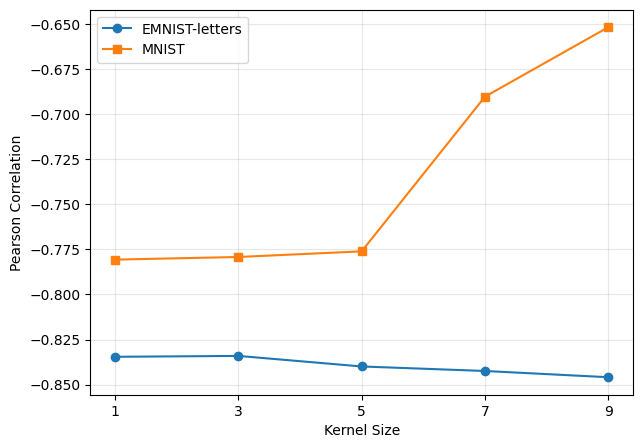

In [70]:
# Визуализация результатов
fig, ax = plt.subplots(figsize=(7, 5))

colors = {'E': 'C0', 'M': 'C1'}
markers = {'E': 'o', 'M': 's'}

# График 1: Коэффициент корреляции
ax.plot(kernel_sizes, emnist_correlations, marker=markers['E'], color=colors['E'])
ax.plot(kernel_sizes, mnist_correlations, marker=markers['M'], color=colors['M'])
ax.set_xticks(kernel_sizes)
ax.set_xlabel("Kernel Size")
ax.set_ylabel("Pearson Correlation")
ax.grid(True, alpha=0.3)
ax.legend(['EMNIST-letters', 'MNIST'])
plt.show()


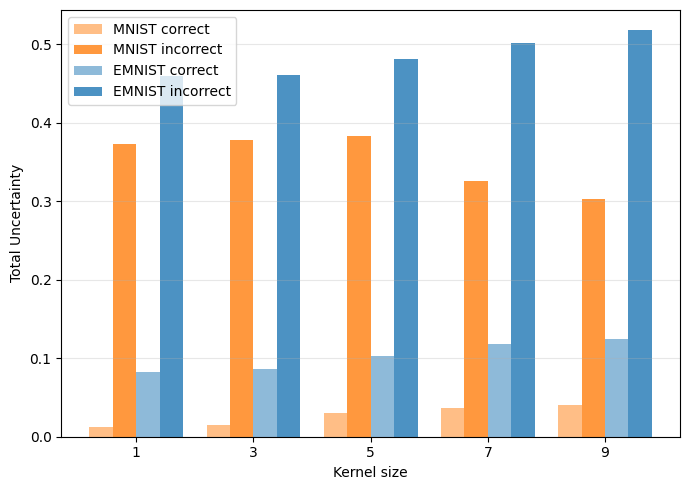

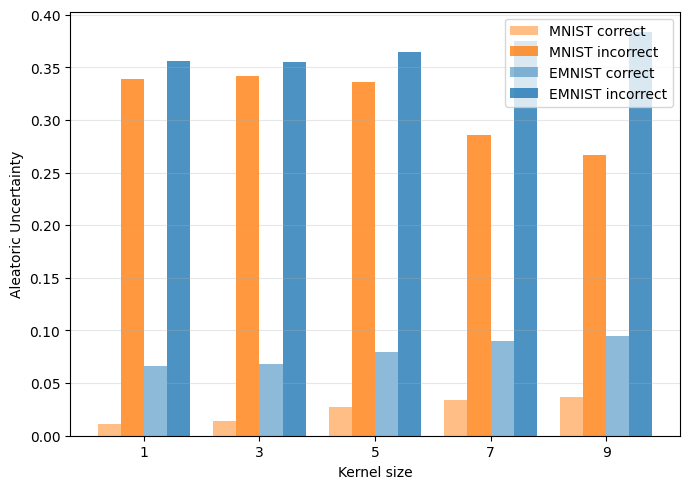

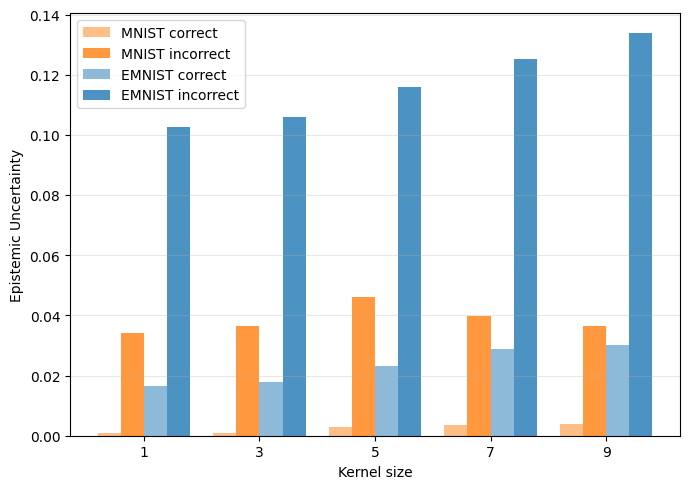

In [71]:
x = np.arange(len(kernel_sizes))
x_labels = [str(k) for k in kernel_sizes]
width = 0.2  # 4 бара в группе
colors = {'E': 'C0', 'M': 'C1'}

configs = [
    ('Total',     mnist_mean_unc_correct,  mnist_mean_unc_incorrect,
     emnist_mean_unc_correct, emnist_mean_unc_incorrect),
    ('Aleatoric', mnist_mean_aunc_correct, mnist_mean_aunc_incorrect,
     emnist_mean_aunc_correct, emnist_mean_aunc_incorrect),
    ('Epistemic', mnist_mean_eunc_correct, mnist_mean_eunc_incorrect,
     emnist_mean_eunc_correct, emnist_mean_eunc_incorrect),
]

for title, m_c, m_i, e_c, e_i in configs:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(x - 1.5*width, m_c, width, label='MNIST correct',    color=colors['M'], alpha=0.5)
    ax.bar(x - 0.5*width, m_i, width, label='MNIST incorrect',  color=colors['M'], alpha=0.8)
    ax.bar(x + 0.5*width, e_c, width, label='EMNIST correct',   color=colors['E'], alpha=0.5)
    ax.bar(x + 1.5*width, e_i, width, label='EMNIST incorrect', color=colors['E'], alpha=0.8)
    ax.set_xlabel('Kernel size')
    ax.set_ylabel(f'{title} Uncertainty')
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Зависимость неопределенности от уровня и типа искажений

In [3]:
corruptions = {
    'Original': lambda x: x,
    # 'WeakBlur': lambda x: gaussian_blur(x, kernel_size=3),
    'MediumBlur': lambda x: gaussian_blur(x, kernel_size=5),
    # 'StrongBlur': lambda x: gaussian_blur(x, kernel_size=7),
    'VeryStrongBlur': lambda x: gaussian_blur(x, kernel_size=9),
}

In [11]:
letters_map = {i: chr(97 + i) for i in range(26)}

Random batch index: 875, image index: 3
IMG[875, 3]=p


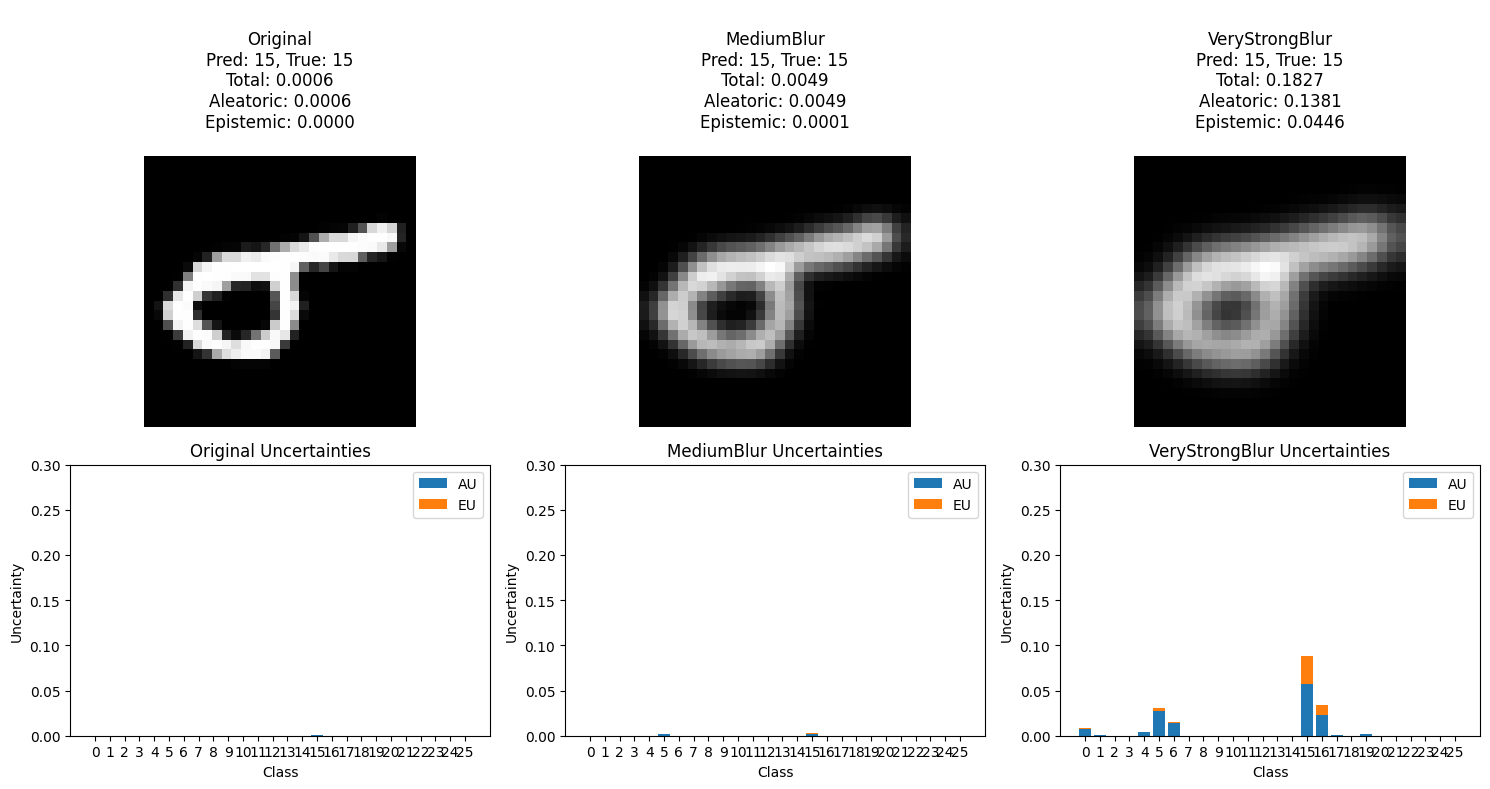

In [16]:
import random

rand_batch_idx = random.randint(0, len(test_loader)-1)
rand_img_idx = random.randint(0, config.test_batch_size-1)
print(f"Random batch index: {rand_batch_idx}, image index: {rand_img_idx}")
img, label = get_img_from_loader(test_loader, batch_idx=rand_batch_idx, img_idx=rand_img_idx, device=config.device)
print(f'IMG[{rand_batch_idx}, {rand_img_idx}]={letters_map[label.item()]}')
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

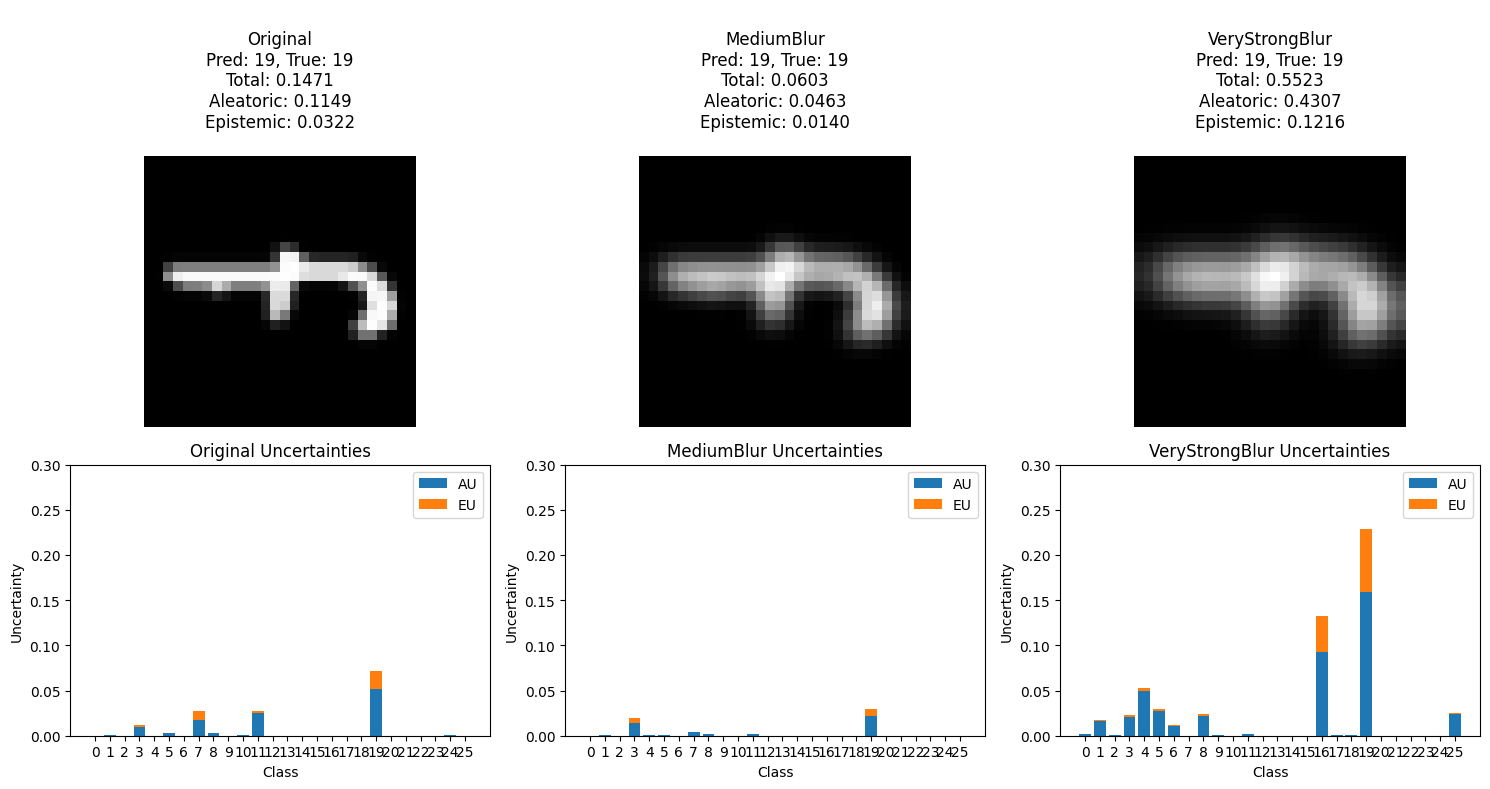

In [15]:
img, label = get_img_from_loader(test_loader, batch_idx=1089, img_idx=2, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

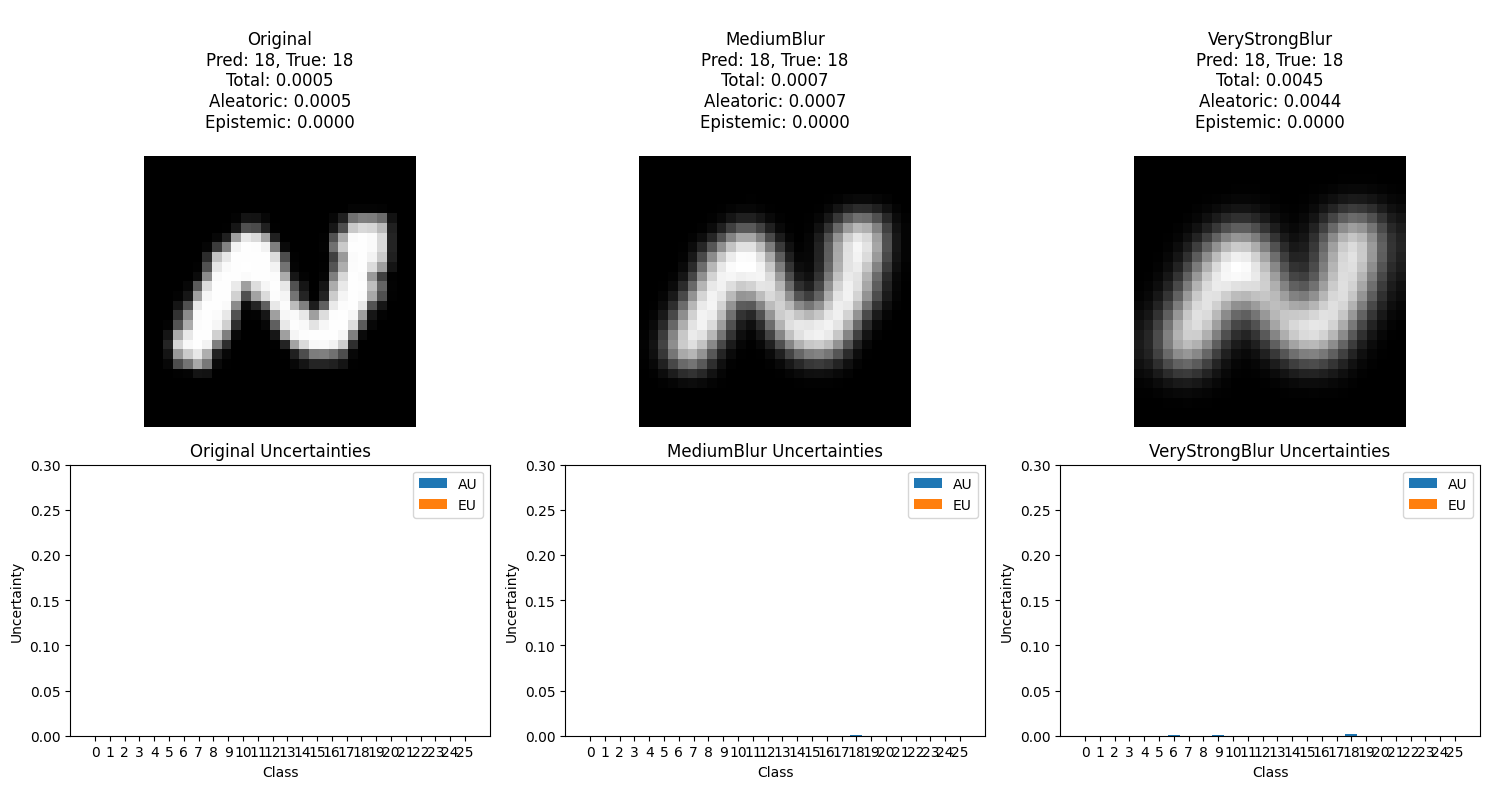

In [12]:
img, label = get_img_from_loader(test_loader, batch_idx=1036, img_idx=9, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

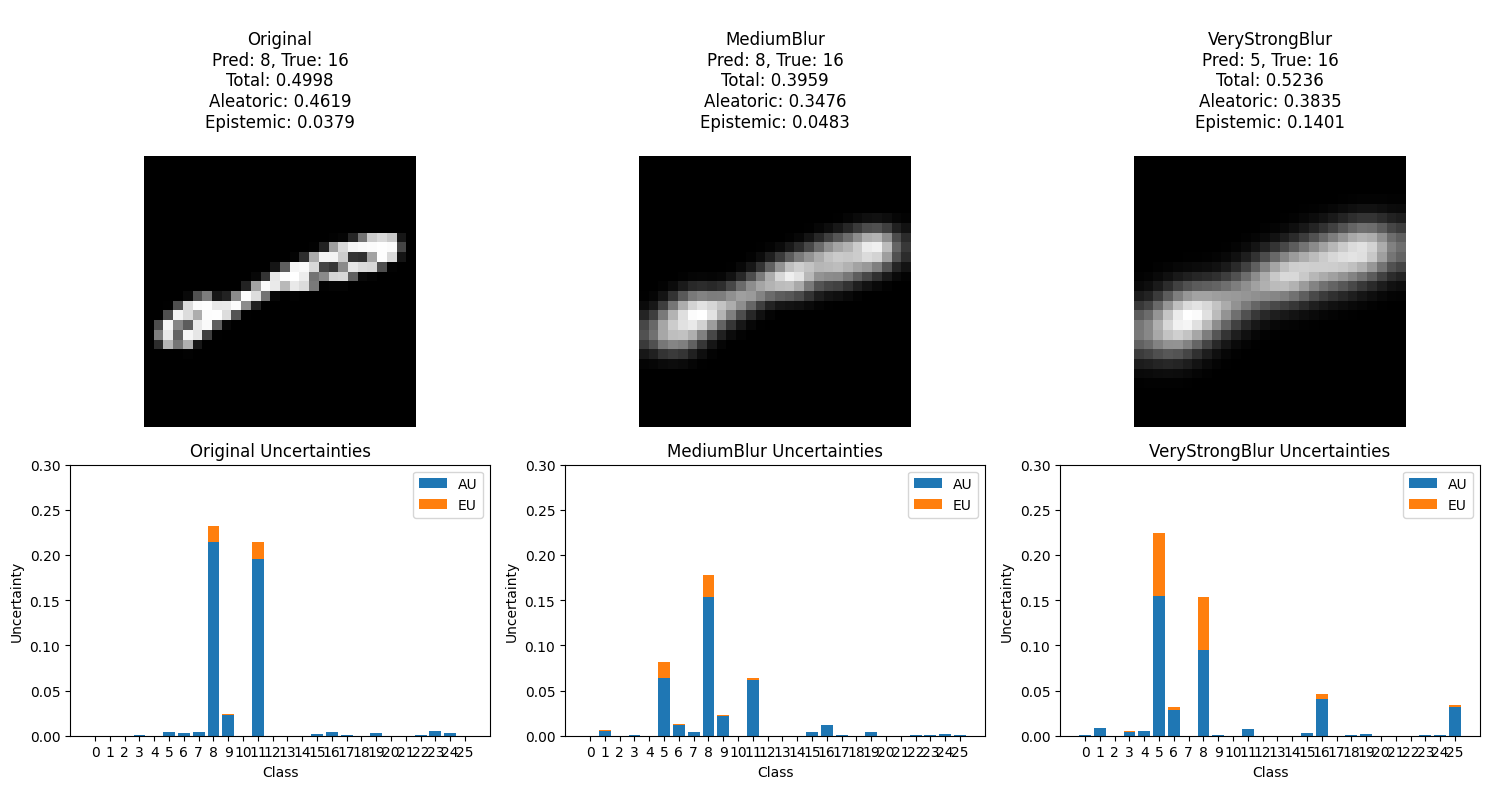

In [6]:
img, label = get_img_from_loader(test_loader, batch_idx=965, img_idx=1, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

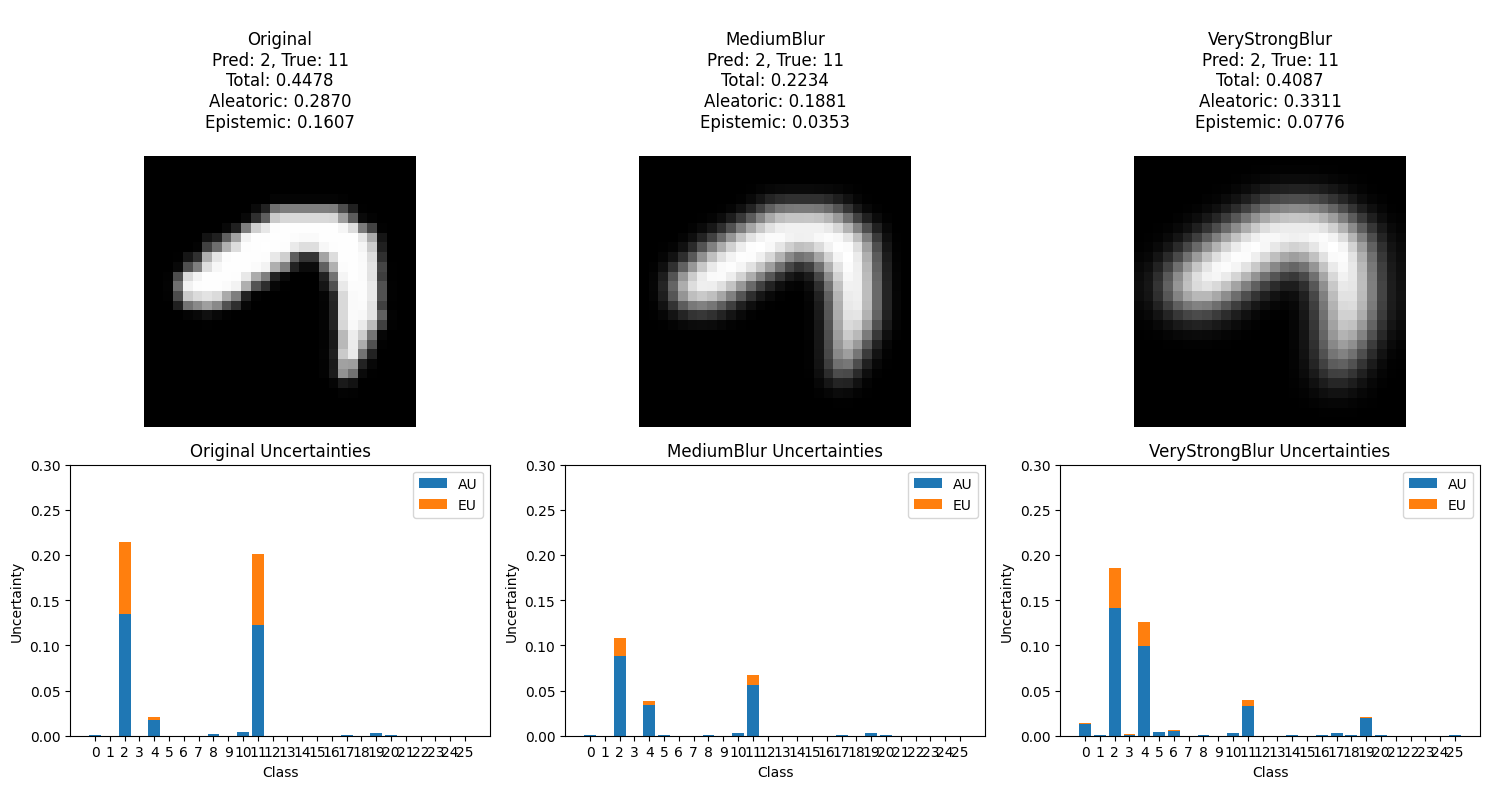

In [7]:
img, label = get_img_from_loader(test_loader, batch_idx=677, img_idx=10, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

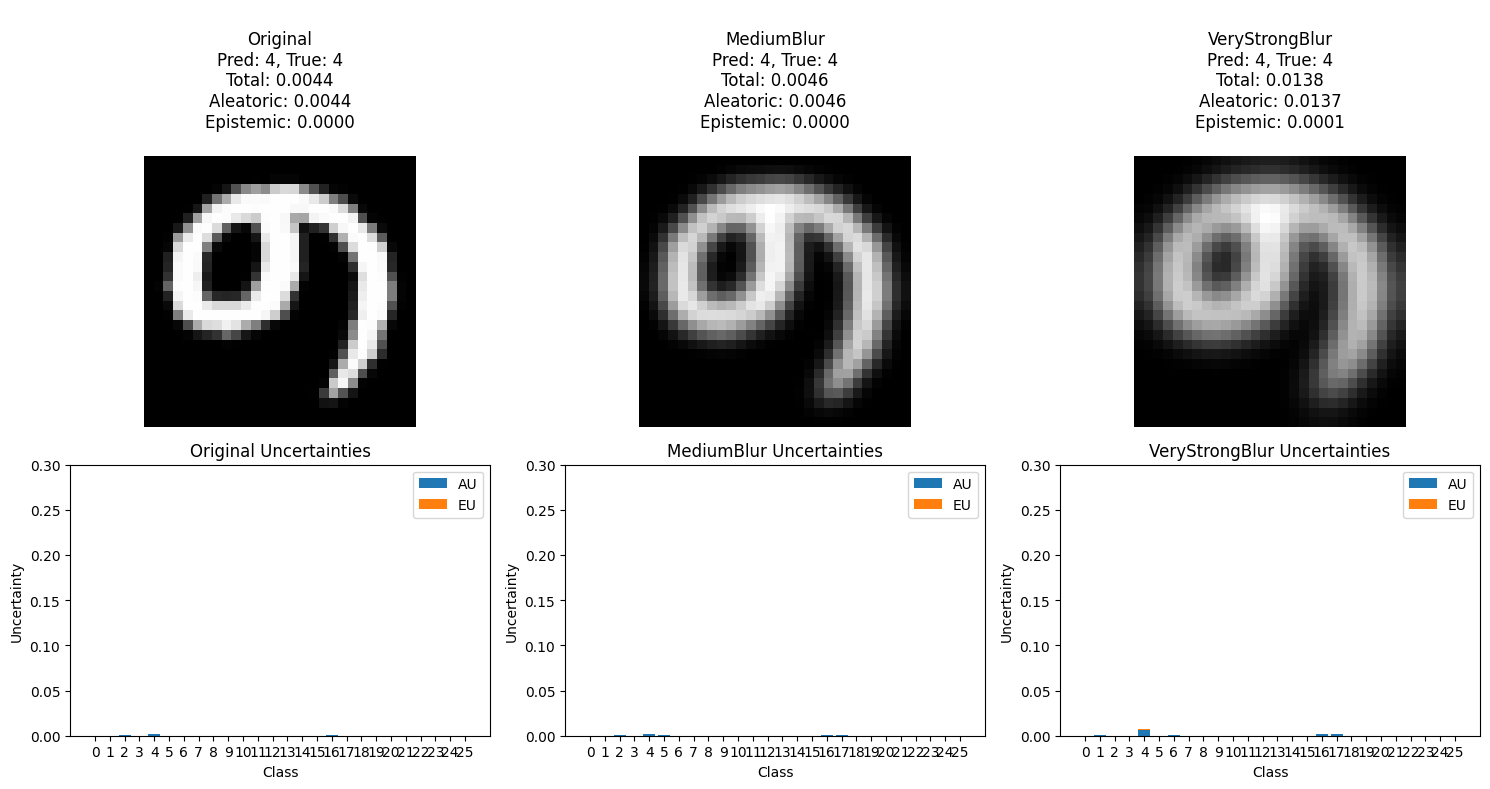

In [8]:
img, label = get_img_from_loader(test_loader, batch_idx=285, img_idx=5, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

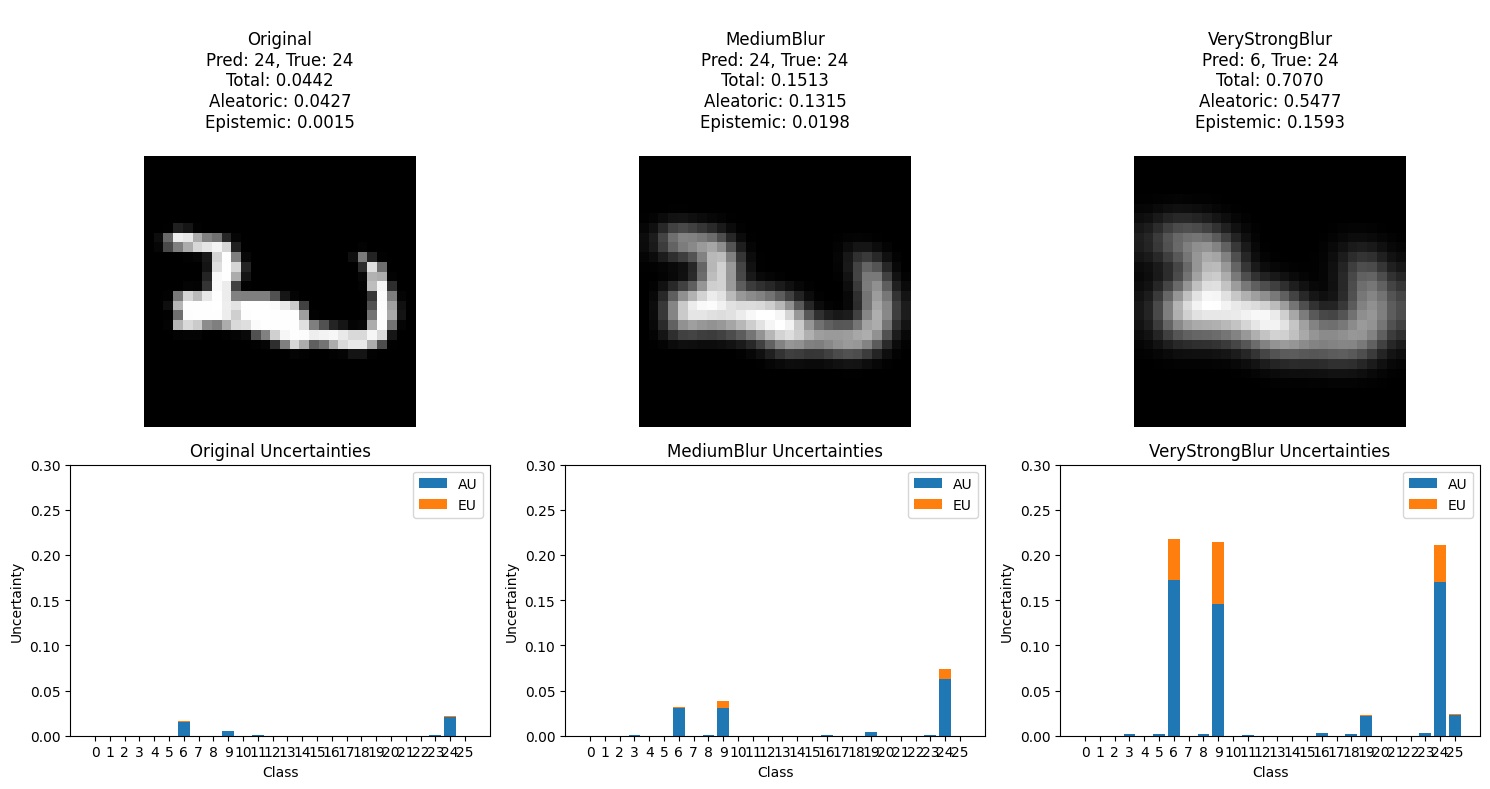

In [9]:
img, label = get_img_from_loader(test_loader, batch_idx=1394, img_idx=12, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)

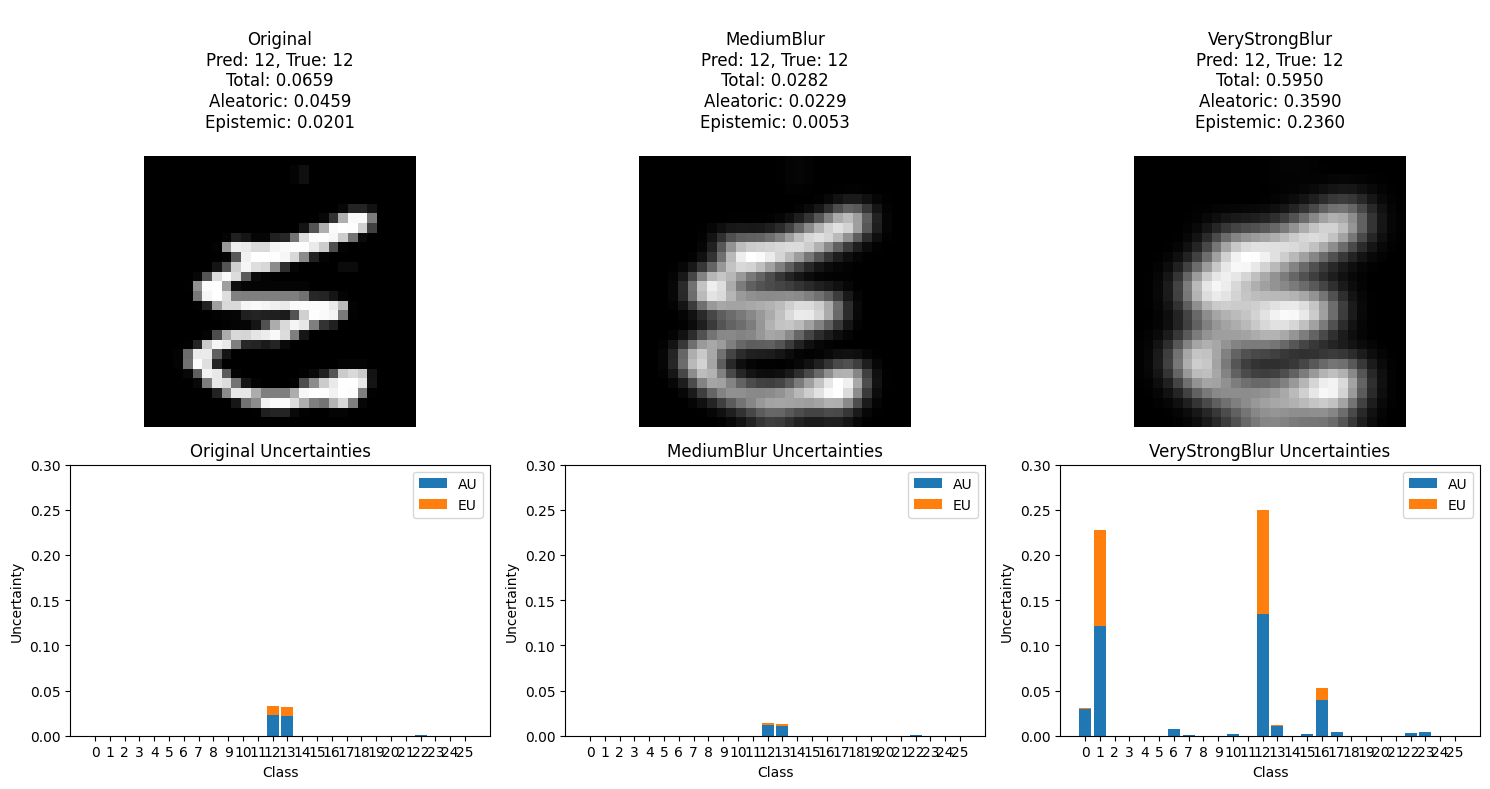

In [10]:
img, label = get_img_from_loader(test_loader, batch_idx=717, img_idx=1, device=config.device)
corruptions_uncertainty(emnist_model, img, label, corruptions, num_classes=26, T=20)